# 03 - Text Branch Training and Evaluation


> Reproducibility note: expensive training commands are shown as code or comments. For viva, these notebooks load the saved final outputs committed in the repository, so the panel can inspect the evidence without rerunning hours of training.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works in Colab and in a local clone. In Colab, uncomment the mount lines if needed.
try:
    from google.colab import drive  # type: ignore
    # drive.mount('/content/drive')
    COLAB_ROOT = Path('/content/drive/MyDrive/fake-news-rl-fusion')
    PROJECT_ROOT = COLAB_ROOT if COLAB_ROOT.exists() else Path.cwd().resolve().parent
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def read_csv(relative_path):
    return pd.read_csv(PROJECT_ROOT / relative_path)

def show_metrics(metrics, keys=('macro_f1', 'accuracy', 'roc_auc', 'balanced_accuracy')):
    rows = []
    for key in keys:
        if key in metrics:
            rows.append({'metric': key, 'value': metrics[key]})
    display(pd.DataFrame(rows))

PROJECT_ROOT = C:\Users\acer\Documents\GitHub\fake-news-rl-fusion


## Purpose
This notebook records the DistilBERT text branch. It is the stronger unimodal branch and forms an important comparison point for fusion.

In [2]:
train_metrics = read_json('outputs/metrics/final_text_model_metrics.json')
output_metrics = read_json('outputs/metrics/final_text_outputs_metrics.json')
print('Device:', train_metrics.get('device'))
print('Best checkpoint:', train_metrics.get('best_checkpoint_path'))
print('Best validation macro F1:', train_metrics.get('best_validation_macro_f1'))
history_rows = []
for row in train_metrics.get('history', []):
    metrics = row.get('validation_metrics', {})
    history_rows.append({'epoch': row['epoch'], 'train_loss': row['train_loss'], 'validation_loss': row['validation_loss'], 'validation_macro_f1': metrics.get('macro_f1'), 'validation_roc_auc': metrics.get('roc_auc')})
history = pd.DataFrame(history_rows)
display(history)

Device: cuda
Best checkpoint: outputs/checkpoints/final_text_model/best_text_model.pt
Best validation macro F1: 0.8477658392613685


,epoch,train_loss,validation_loss,validation_macro_f1,validation_roc_auc
0,1,0.402891,0.356731,0.842282,0.921794
1,2,0.259960,0.386915,0.841234,0.922255
2,3,0.131209,0.473776,0.847766,0.918541


,split,rows,macro_f1,accuracy,roc_auc
0,test,3780,0.838769,0.838889,0.912095
1,train,18893,0.988247,0.988250,0.999246
2,validation,3798,0.847766,0.847815,0.918541


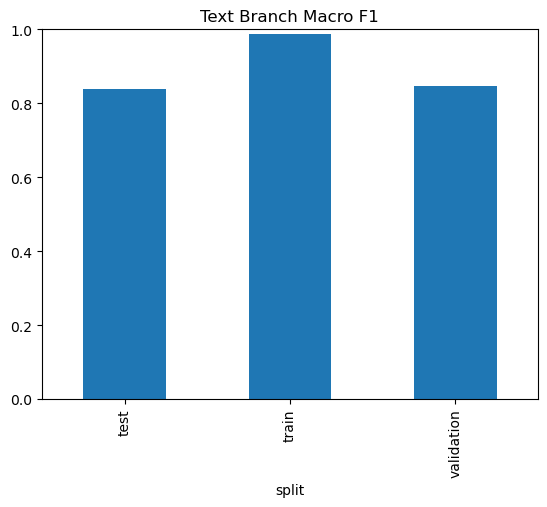

In [3]:
rows = []
for split, payload in output_metrics['splits'].items():
    m = payload['metrics']
    rows.append({'split': split, 'rows': payload['rows'], 'macro_f1': m['macro_f1'], 'accuracy': m['accuracy'], 'roc_auc': m['roc_auc']})
text_eval = pd.DataFrame(rows).sort_values('split')
display(text_eval)
text_eval.plot.bar(x='split', y='macro_f1', legend=False, title='Text Branch Macro F1')
plt.ylim(0, 1)
plt.show()

In [4]:
for split in ['validation', 'test']:
    print(split.upper())
    cm = output_metrics['splits'][split]['metrics']['confusion_matrix']
    display(pd.DataFrame(cm, index=['true_real', 'true_fake'], columns=['pred_real', 'pred_fake']))

VALIDATION


,pred_real,pred_fake
true_real,1644,223
true_fake,355,1576


TEST


,pred_real,pred_fake
true_real,1637,229
true_fake,380,1534


In [5]:
# Reproduction command, expensive:
# %cd /content/drive/MyDrive/fake-news-rl-fusion
# !python scripts/train_text_model.py --config configs/final_text_model.yaml
# !python scripts/infer_text_model.py --config configs/final_text_model.yaml